# 07 — Linear regression

Ordinary least squares (closed-form via QR), ridge regression, and
polynomial features – all from `numethods.regression`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 4.5), "figure.dpi": 110, "axes.grid": True})

from numethods import OLSRegression, RidgeRegression, polynomial_features


## Synthetic linear data

slope     = 2.5820  (truth 2.5)
intercept = 0.7059 (truth 1.0)
R^2       = 0.9704


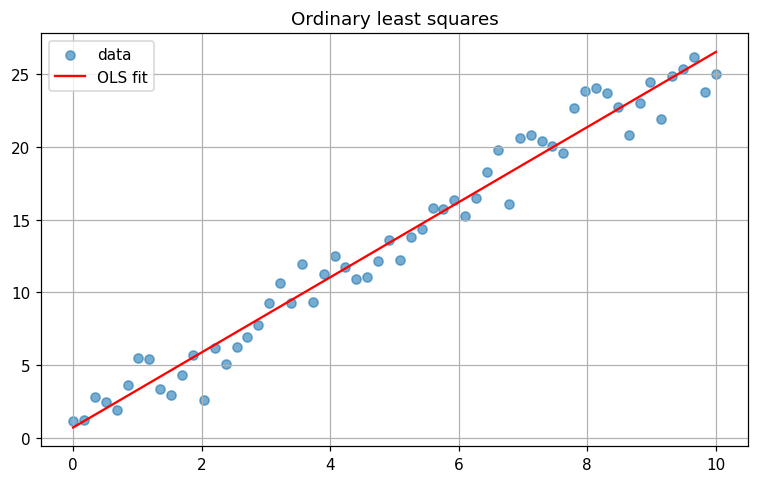

In [2]:
rng = np.random.default_rng(0)
n = 60
X = np.linspace(0, 10, n).reshape(-1, 1)
y = 2.5 * X[:, 0] + 1.0 + rng.normal(0, 1.5, n)

ols = OLSRegression().fit(X, y)
print(f'slope     = {ols.coef_[0]:.4f}  (truth 2.5)')
print(f'intercept = {ols.intercept_:.4f} (truth 1.0)')
print(f'R^2       = {ols.score(X, y):.4f}')

x_pred = np.linspace(0, 10, 100).reshape(-1, 1)
fig, ax = plt.subplots()
ax.scatter(X, y, alpha=0.6, label='data')
ax.plot(x_pred, ols.predict(x_pred), 'r-', label='OLS fit')
ax.legend(); ax.set_title('Ordinary least squares'); fig.tight_layout(); plt.show()


## Polynomial regression with ridge regularization

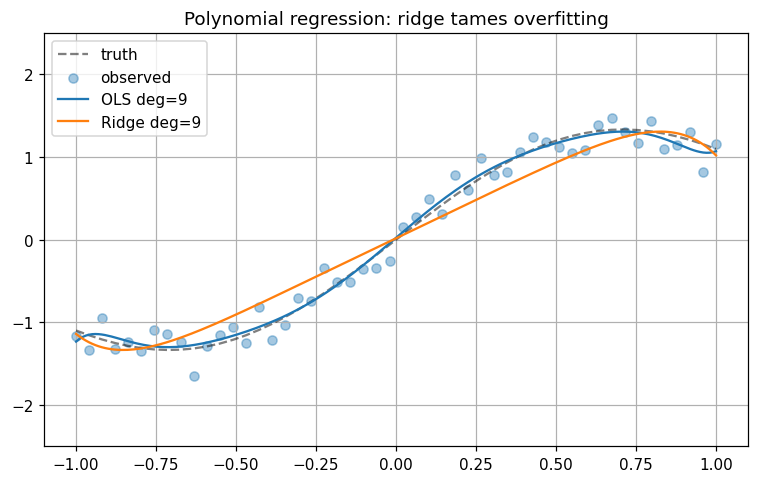

In [3]:
# A nonlinear true function with noise
xs = np.linspace(-1, 1, 50).reshape(-1, 1)
y_true = np.sin(2.5 * xs[:, 0]) + 0.5 * xs[:, 0]
y_obs = y_true + rng.normal(0, 0.15, xs.size)

degree = 9
Xp = polynomial_features(xs, degree)

unreg = OLSRegression().fit(Xp, y_obs)
ridged = RidgeRegression(alpha=1.0).fit(Xp, y_obs)

x_dense = np.linspace(-1, 1, 200).reshape(-1, 1)
Xp_dense = polynomial_features(x_dense, degree)

fig, ax = plt.subplots()
ax.plot(xs, y_true, 'k--', alpha=0.5, label='truth')
ax.scatter(xs, y_obs, alpha=0.4, label='observed')
ax.plot(x_dense, unreg.predict(Xp_dense),  label=f'OLS deg={degree}')
ax.plot(x_dense, ridged.predict(Xp_dense), label=f'Ridge deg={degree}')
ax.set_ylim(-2.5, 2.5); ax.legend(); ax.set_title('Polynomial regression: ridge tames overfitting')
fig.tight_layout(); plt.show()


Ridge shrinks the high-order coefficients toward zero, eliminating the wild oscillations at the boundaries. This notebook demonstrates `numethods.regression`.